# Project Situated AI Assignment 2: Robotics and Reinforcement Learning

This notebook provides a quickstart for training RL agents on Gymnasium Robotics environments using RL Baselines3 Zoo.

## Part 1: Setup

Run these cells once to install dependencies.

### Collab Setup

In [1]:
# Install system dependencies (Colab only - skip if running locally)
!apt-get update && apt-get install -q -y swig cmake ffmpeg freeglut3-dev xvfb

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:3 https://cli.github.com/packages stable InRelease [3,917 B]
Get:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [83.8 kB]
Get:6 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,315 kB]
Hit:7 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:8 https://cli.github.com/packages stable/main amd64 Packages [356 B]
Get:9 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,665 kB]
Get:11 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:12 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:13 https://ppa.launchpadcontent.net/graphics-dr

In [ ]:
# Setup virtual display for video recording (Colab only)
import os
os.system("Xvfb :1 -screen 0 1024x768x24 &")
os.environ['DISPLAY'] = ':1'

In [2]:
# Mount your drive to the session
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Specific to my setup in drive (below)

In [3]:
PROJECT_PATH = "/content/drive/MyDrive/psai/robotics_rl"
%cd {PROJECT_PATH}
!ls

/content/drive/MyDrive/psai/robotics_rl
hyperparams_comparison_her.yaml  modified_env.py  task_2_and_3.ipynb
hyperparams.txt			 README.md
logs				 record_video.py


### General Setup

In [4]:
# Install Python packages
!pip install -q rl-zoo3
!pip install -q gymnasium-robotics
# only for task 1.5 - skip here
# !pip install -q -e git+https://github.com/Farama-Foundation/Gymnasium-Robotics.git#egg=gymnasium-robotics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.0/78.0 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.1/91.1 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.2/93.2 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 18.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.2/26.2 MB 91.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 150.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.5/852.5 kB 68.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 24.3 MB/s eta 0:00:00


In [ ]:
# Create wrapper for record_video (rl_zoo3.record_video doesn't support --gym-packages)
with open('record_video.py', 'w') as f:
    f.write(
        '#!/usr/bin/env python\n'
        'import gymnasium_robotics\n'
        'import runpy\n'
        'import modified_env\n'
        'runpy.run_module("rl_zoo3.record_video", run_name="__main__")\n'
    )

## Part 2: Configure Hyperparameters

RL Zoo expects hyperparameters in a YAML file. Modify these to experiment with different settings.

In [ ]:
import yaml

hyperparams = {
    "FetchReachDense-v4": {
        "n_timesteps": 300_000,
        "policy": "MultiInputPolicy",
        "learning_rate": 1e-3,
        "batch_size": 256,
        "buffer_size": 1_000_000,
        "learning_starts": 5_000,
        "train_freq": 1,
        "gradient_steps": 1,
        "gamma": 0.98,
        "tau": 0.02,
        "policy_kwargs": "dict(net_arch=[256, 256])",
    }
}

with open("hyperparams.yaml", "w") as f:
    yaml.dump(hyperparams, f, sort_keys=False)

print("Hyperparameters saved to hyperparams.yaml")

Hyperparameters saved to hyperparams.yaml


## Part 3: Train the Agent

Train a DDPG agent on the FetchReachDense-v4 environment. Training logs are saved to `logs/`.

In [ ]:
!python -m rl_zoo3.train --algo ddpg --env FetchReachDense-v4 \
    --gym-packages gymnasium_robotics -c hyperparams.yaml

========== FetchReachDense-v4 ==========
Seed: 2217222938
Loading hyperparameters from: hyperparams.yaml
Default hyperparameters for environment (ones being tuned will be overridden):
OrderedDict([('batch_size', 256),
             ('buffer_size', 1000000),
             ('gamma', 0.98),
             ('gradient_steps', 1),
             ('learning_rate', 0.001),
             ('learning_starts', 5000),
             ('n_timesteps', 300000),
             ('policy', 'MultiInputPolicy'),
             ('policy_kwargs', 'dict(net_arch=[256, 256])'),
             ('tau', 0.02),
             ('train_freq', 1)])
Using 1 environments
Creating test environment
Using cpu device
Log path: logs/ddpg/FetchReachDense-v4_4
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 50       |
|    ep_rew_mean     | -11.3    |
|    success_rate    | 0        |
| time/              |          |
|    episodes        | 4        |
|    fps             | 1786     |
|    time_elapse

## Part 4: Evaluate the Agent

Run the trained agent and see its performance metrics.

In [ ]:
!python -m rl_zoo3.enjoy --algo ddpg --env FetchReachDense-v4 \
    --gym-packages gymnasium_robotics --no-render -n 500 -f logs/

Loading latest experiment, id=4
Loading logs/ddpg/FetchReachDense-v4_4/FetchReachDense-v4.zip
Episode Reward: -1.20
Episode Length 50
Episode Reward: -0.87
Episode Length 50
Episode Reward: -0.64
Episode Length 50
Episode Reward: -1.85
Episode Length 50
Episode Reward: -0.84
Episode Length 50
Episode Reward: -0.75
Episode Length 50
Episode Reward: -1.37
Episode Length 50
Episode Reward: -0.74
Episode Length 50
Episode Reward: -0.88
Episode Length 50
Episode Reward: -0.86
Episode Length 50
Success rate: 100.00%
10 Episodes
Mean reward: -1.00 +/- 0.35
Mean episode length: 50.00 +/- 0.00


## Part 5: Record and View Video

Record a video of the trained policy to visually evaluate performance.

In [ ]:
import os
#os.environ['MUJOCO_GL'] = 'egl'
os.environ['MUJOCO_GL'] = 'glfw'
# for mac
import mujoco

In [ ]:
# record_video.py is a wrapper that pre-loads gymnasium_robotics
# (rl_zoo3.record_video doesn't support --gym-packages)
#!pip install -q 'gymnasium[other]'
!python record_video.py --algo ddpg --env FetchReachDense-v4 -f logs/ -n 1000

2026-01-24 20:13:16.002894: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769285596.024562    3954 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769285596.031035    3954 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769285596.046558    3954 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769285596.046588    3954 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769285596.046591    3954 computation_placer.cc:177] computation placer alr

In [ ]:
import base64
from pathlib import Path
from IPython import display as ipythondisplay

def show_videos(video_path, prefix=""):
    """Display MP4 videos from a folder in the notebook."""
    html = []
    for mp4 in Path(video_path).glob(f"{prefix}*.mp4"):
        video_b64 = base64.b64encode(mp4.read_bytes()).decode('ascii')
        html.append(f'''<video alt="{mp4}" autoplay loop controls style="height: 400px;">
            <source src="data:video/mp4;base64,{video_b64}" type="video/mp4" />
        </video>''')
    ipythondisplay.display(ipythondisplay.HTML(data="<br>".join(html)))

In [ ]:
# Display the recorded video
# Update the path if your experiment ID differs (check logs/ddpg/ folder)
show_videos('logs/ddpg/FetchReachDense-v4_3/videos/')

### Useful Commands

```bash
# Train with a different algorithm
python -m rl_zoo3.train --algo sac --env FetchReachDense-v4 --gym-packages gymnasium_robotics -c hyperparams.yaml

# Train with a specific seed (for reproducibility)
python -m rl_zoo3.train --algo ddpg --env FetchReachDense-v4 --gym-packages gymnasium_robotics -c hyperparams.yaml --seed 42

# Load best model instead of final model
python -m rl_zoo3.enjoy --algo ddpg --env FetchReachDense-v4 --gym-packages gymnasium_robotics -f logs/ --load-best
```

## Task 2

In [ ]:
!pip install gymnasium_robotics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.2/26.2 MB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 92.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.5/852.5 kB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 19.4 MB/s eta 0:00:00


##### Necessary pips imports and setup, to avoid scrolling


In [ ]:
# Install system dependencies (Colab only - skip if running locally)
!apt-get update && apt-get install -q -y swig cmake ffmpeg freeglut3-dev xvfb

# Setup virtual display for video recording (Colab only)
import os
os.system("Xvfb :1 -screen 0 1024x768x24 &")
os.environ['DISPLAY'] = ':1'

# Mount your drive to the session
from google.colab import drive
drive.mount('/content/drive')

PROJECT_PATH = "/content/drive/MyDrive/psai/robotics_rl"
%cd {PROJECT_PATH}
!ls

# Install Python packages
!pip install -q rl-zoo3
!pip install -q -e git+https://github.com/Farama-Foundation/Gymnasium-Robotics.git#egg=gymnasium-robotics
!pip install -q gymnasium



Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:3 https://cli.github.com/packages stable InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading packag

KeyboardInterrupt: 

In [ ]:
!pip install -q rl-zoo3
!pip install -q gymnasium-robotics

  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for gymnasium-robotics (pyproject.toml) ... done


###### FetchPushDense: HER + TQC + Learning improvements
- Using TQC as it handles overestimation very well. using multiple critics and top performer truncation.

- Using HER. This here is probably one of the most significant changes. Using HER in this task, changes it from a sparse reward task to a denser one. The issue with fetchpush without HER is that the agent will not actually learn anything as it never will be rewarded (extremely rarely so). It might take millions of episodes before the agent stumbles upon the target. HER converts past experiences as learning steps, if it achieved some other target (not the actual target) it can view that experience as a success anyhow. This allows the agent to learn from the very get go and not need to wait for this extremely rare reward signal.

- Using reward shaping, bonus points for gripper being near block. Rewarding contact is important for this task, as prolonger contact is what the agent should strive for in order to push the block to the target.

- Using observation expansion. Adding the relative distance vector expands makes it easier for the model to learn direct links between its observed state and its task, i.e. closing the distance between itself and the object to start pushing it.

In [ ]:
import yaml

hyperparams = {
    "FetchPushModified-v0": {
        "n_timesteps": 1000000,
        "policy": "MultiInputPolicy",
        "learning_rate": 0.001,
        "batch_size": 2048,
        "buffer_size": 1000000,
        "gamma": 0.95,
        "tau": 0.05,
        "learning_starts": 1000,
        "policy_kwargs": "dict(net_arch=[512, 512, 512], n_quantiles=25)",
        "replay_buffer_class": "HerReplayBuffer",
        "replay_buffer_kwargs": "dict(n_sampled_goal=4, goal_selection_strategy='future')",
    }
}

with open('hyperparams.yaml', 'w') as f:
    yaml.dump(hyperparams, f, sort_keys=False)

print("Hyperparameters saved to hyperparams.yaml")

Hyperparameters saved to hyperparams.yaml


In [ ]:
# %%writefile modified_env.py
import gymnasium as gym
import numpy as np
from gymnasium import Wrapper
import gymnasium_robotics

# Essential: This registers the base Fetch environments
gymnasium_robotics.register_robotics_envs()

class FetchPushModifiedWrapper(Wrapper):
    def __init__(self, env, contact_bonus=0.1):
        super().__init__(env)
        self.contact_bonus = contact_bonus

        old_shape = self.env.observation_space['observation'].shape[0]
        new_shape = old_shape + 3
        self.observation_space['observation'] = gym.spaces.Box(
            low=-np.inf, high=np.inf, shape=(new_shape,), dtype=np.float32
        )

    def _get_relative_dist(self, obs):
        """
        Here we get the distance from gripper to object (x,y,z)
        """
        gripper_pos = obs['observation'][0:3]
        object_pos = obs['observation'][3:6]
        return object_pos - gripper_pos

    def reset(self, **kwargs):
        """
        Reset with adding the relative distance to the observation
        """
        obs, info = self.env.reset(**kwargs)
        rel_dist = self._get_relative_dist(obs)
        obs['observation'] = np.concatenate([obs['observation'], rel_dist])
        return obs, info

    def step(self, action):
        """
        Modified step with reward bonus for contact. Rewarding contact is important
        for this task, as prolonger contact is what the agent should strive for
        in order to push the block to the target.
        """
        obs, reward, terminated, truncated, info = self.env.step(action)
        rel_dist = self._get_relative_dist(obs)
        obs['observation'] = np.concatenate([obs['observation'], rel_dist])

        if np.linalg.norm(rel_dist) < 0.05:
            reward += self.contact_bonus

        return obs, reward, terminated, truncated, info

gym.register(
    id="FetchPushModified-v0",
    entry_point=lambda **kwargs: FetchPushModifiedWrapper(
        gym.make("FetchPush-v4", reward_type="dense", **kwargs)
    ),
    max_episode_steps=50,
)

/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:636: UserWarning: WARN: Overriding environment FetchSlide-v1 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:636: UserWarning: WARN: Overriding environment FetchSlide-v4 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:636: UserWarning: WARN: Overriding environment FetchPickAndPlace-v1 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:636: UserWarning: WARN: Overriding environment FetchPickAndPlace-v4 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py

In [ ]:
# Train with a specific seed (for reproducibility)
!python -m rl_zoo3.train --algo tqc --env FetchPushModified-v0 --gym-packages modified_env -c hyperparams.yaml --seed 42 --save-freq 100000

Streaming output truncated to the last 5000 lines.
|    ep_rew_mean     | 1.3      |
|    success_rate    | 0.84     |
| time/              |          |
|    episodes        | 9932     |
|    fps             | 34       |
|    time_elapsed    | 14238    |
|    total_timesteps | 496600   |
| train/             |          |
|    actor_loss      | -0.309   |
|    critic_loss     | 0.000769 |
|    ent_coef        | 0.00144  |
|    ent_coef_loss   | 0.848    |
|    learning_rate   | 0.001    |
|    n_updates       | 495599   |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 50       |
|    ep_rew_mean     | 1.29     |
|    success_rate    | 0.84     |
| time/              |          |
|    episodes        | 9936     |
|    fps             | 34       |
|    time_elapsed    | 14244    |
|    total_timesteps | 496800   |
| train/             |          |
|    actor_loss      | -0.354   |
|    critic_loss     | 0.00066 

In [ ]:
!python -m rl_zoo3.train --algo tqc --env FetchPushModified-v0 \
    -i logs/tqc/FetchPushModified-v0_4/rl_model_500000_steps.zip \
    --gym-packages modified_env \
    -c hyperparams.yaml \
    --seed 42 \
    --save-freq 100000 \
    -n 500000

2026-01-26 22:47:21.577446: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769467641.610161    8823 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769467641.620225    8823 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769467641.645803    8823 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769467641.645882    8823 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769467641.645891    8823 computation_placer.cc:177] computation placer alr

###### Training Plot
- Due to compute limitations our training stopped somewhat halfway of 1e6 timesteps. The best models still has very high performance, achieving 100% success rate when we use the enjoy command (use the best model).
- The plot below shows the reward and success rate over time in the incremental tests that are stored in our evaluations.npz folder. We opted for using the interval test data that is produced when training instead of other progress data, only due to availability. Due to some issues with colab, the monitor data is empty for one.
- Quite early on, around 200k timesteps, it would seem our model learned how to make contact regularly at around this point, thus triggering the bonus reward we added in our wrapper.
- It is difficult to say exactly which added component led to the model achieving somewhat good performance. The HER undoubtedly leads to a strong surge in learning, however, the reward modeling and observation expansion are likely to have contributed. Interesting remains the early good performance our model achieved. Due to the nature of the incremental data that we do have access to, we cannot see the finer grains of the first 2.5e4 steps our model trained.

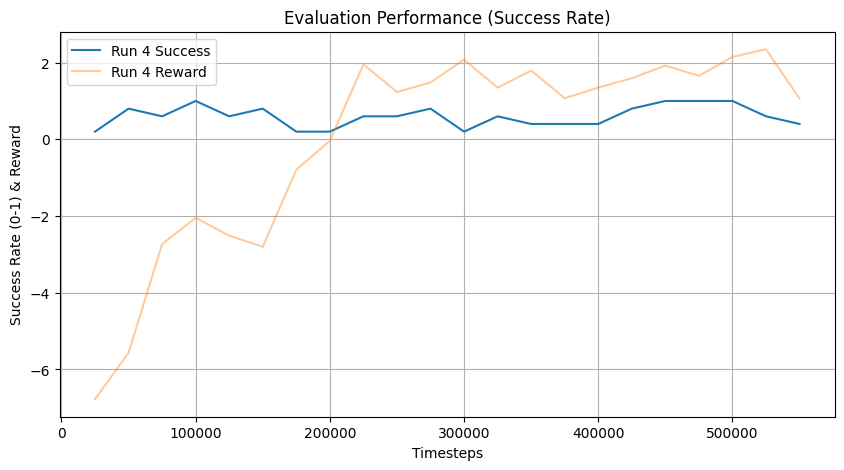

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import glob

files = sorted(glob.glob("logs/tqc/FetchPushModified-v0_4/evaluations.npz"))

plt.figure(figsize=(10, 5))

for f in files:
    data = np.load(f)
    run_id = f.split('/')[-2].split('_')[-1]

    x = data['timesteps']
    y_reward = np.mean(data['results'], axis=1)
    y_success = np.mean(data['successes'], axis=1)

    # if you dont want to see the mean of tests, uncomment two lines below and
    # comment the two under
    # plt.plot(x, data['successes'], label=f"Run {run_id} Success")
    # plt.plot(x, data['results'], label=f"Run {run_id} Reward", alpha=0.4) # reward line
    plt.plot(x, y_success, label=f"Run {run_id} Success")
    plt.plot(x, y_reward, label=f"Run {run_id} Reward", alpha=0.4) # reward line



plt.title("Evaluation Performance (Success Rate)")
plt.xlabel("Timesteps")
plt.ylabel("Success Rate (0-1) & Reward")
plt.legend()
plt.grid(True)
plt.show()

Loading the (partially) trained agent and testing it

In [ ]:
!python -m rl_zoo3.enjoy --algo tqc --env FetchPushModified-v0 --gym-packages modified_env -f logs/ --load-checkpoint 500000 \
    --exp-id 4 -n 500 --no-render


2026-01-26 22:40:56.027553: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769467256.060091    7177 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769467256.069938    7177 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769467256.094616    7177 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769467256.094653    7177 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769467256.094661    7177 computation_placer.cc:177] computation placer alr

###### Recording the video


In [ ]:
!python record_video.py --algo tqc --env FetchPushModified-v0 -f logs/ -n 1000 --exp-id 4 --load-best

/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:636: UserWarning: WARN: Overriding environment FetchSlide-v1 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:636: UserWarning: WARN: Overriding environment FetchSlide-v4 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:636: UserWarning: WARN: Overriding environment FetchPickAndPlace-v1 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:636: UserWarning: WARN: Overriding environment FetchPickAndPlace-v4 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py

###### Showing the video

In [ ]:
show_videos("/content/drive/MyDrive/psai/robotics_rl/logs/tqc/FetchPushModified-v0_4/videos/")

## Task 3

<!-- RQ: How does TQC vs TQC (enhanced) with ... augmentation in FetchSlideDense
How do awarding more points for pick up, gripping, and reaching the goal, impact the performance of TQCthe  in FetchPickAndPlace environment impact
learning rate and final performance.
- diff between in the early training dynamics ~ Mateus
- 3 minimum seeds for each algo,
- 100k steps / 200k steps (TBD) -->

**RQ:** How does TQC wrapped perform against standard TQC in the FetchPickAndPlace environment throughout the early training dynamics?





In [ ]:
# FetchPickAndPlace-v4_1 holds seed 42 TQC + HER first 100 (two other seeds
# are in the other branch)



#### The hyperparams for both TQC algorithms

###### TQC (Truncated Quantile Critics)
* **`n_quantiles: 25`**: Models a distribution of possible rewards rather than just the mean, helping the agent understand the uncertainty of robotic contact (*Kuznetsov et al., 2020*).
* **`top_quantiles_to_drop_per_net: 2`**: Here we truncate 2 top performing quantiles, in hopes of removing outliers/ over estimations.
* **`batch_size: 2048`**: Large sample size required to accurately estimate the 25 reward quantiles across multiple critics. We have very diverse data with TQC and HER, a sizy batch is important to encompass all this
* **`gamma: 0.98`**: Ensure the latter parts of the task sequence are not seen as less important, reducing this value, which we tried on earlier attempts, is not optimal.
* **`learning_rate: 0.001`**: Some papers opt for two values, one for actor, one for critic. We chose this value as it is easier to work with, easier to tune. Otherwise pretty standard and balances learning fast with HER, and stability for our TQC learning algorithm.
* **`buffer_size: 100000`**: We set this value to be the same as our total timesteps, our agent can learn from all experiences.
* **`n_sampled_goal: 4`**: For each real experience, the agent can learn from 4 other 'fake' experiences. Improving the rate at which we learn.
* **`tau: 0.4`**: The polyak avg coeff is set quite high. It updates our target network more freqently with our online networks, have a closer follow-up. Due to the density of information in with HER we can update the target more often.
* **`n_timesteps: 100000`**: Our experiment revolves around measuring performance and learning in the initial stages of learning, going beyond a 1e5 is not relevant to our research question.

###### References
* **HER (Hindsight Experience Replay):** Andrychowicz, M., et al. (2017). *"Hindsight Experience Replay."*
* **TQC Optimization:** Kuznetsov, A., et al. (2020). *"Controlling Overestimation Bias with Truncated Quantile Critics."*

In [ ]:
import yaml

hyperparams = {
    "FetchPickAndPlaceModified-v0": {
            "n_timesteps": 100000,
            "policy": "MultiInputPolicy",
            "learning_rate": 0.001,
            "batch_size": 2048,
            "buffer_size": 100000,
            "gamma": 0.98,
            "tau": 0.05,
            # "replay_buffer_class": "HerReplayBuffer",
            # "replay_buffer_kwargs": "dict(n_sampled_goal=4, goal_selection_strategy='future')",
            "policy_kwargs": "dict(net_arch=[512, 512, 512], n_quantiles=25)",
            "top_quantiles_to_drop_per_net": 2,
        },
    "FetchPickAndPlace-v4": {
            "n_timesteps": 100000,
            "policy": "MultiInputPolicy",
            "learning_rate": 0.001,
            "batch_size": 2048,
            "buffer_size": 100000,
            "gamma": 0.98,
            "tau": 0.05,
            # "replay_buffer_class": "HerReplayBuffer",
            # "replay_buffer_kwargs": "dict(n_sampled_goal=4, goal_selection_strategy='future')",
            "policy_kwargs": "dict(net_arch=[512, 512, 512], n_quantiles=25)",
            "top_quantiles_to_drop_per_net": 2,
        }
}

with open('hyperparams_comparison.yaml', 'w') as f:
    yaml.dump(hyperparams, f, sort_keys=False)

print("Hyperparameters saved to hyperparams_comparison.yaml")

Hyperparameters saved to hyperparams_comparison.yaml


In [5]:
import yaml

hyperparams_her = {
    "FetchPickAndPlaceModified-v0": {
            "n_timesteps": 100000,
            "policy": "MultiInputPolicy",
            "learning_rate": 0.001,
            "batch_size": 2048,
            "buffer_size": 100000,
            "gamma": 0.98,
            "tau": 0.05,
            "replay_buffer_class": "HerReplayBuffer",
            "replay_buffer_kwargs": "dict(n_sampled_goal=4, goal_selection_strategy='future')",
            "policy_kwargs": "dict(net_arch=[512, 512, 512], n_quantiles=25)",
            "top_quantiles_to_drop_per_net": 2,
        },
    "FetchPickAndPlace-v4": {
            "n_timesteps": 100000,
            "policy": "MultiInputPolicy",
            "learning_rate": 0.001,
            "batch_size": 2048,
            "buffer_size": 100000,
            "gamma": 0.98,
            "tau": 0.05,
            "replay_buffer_class": "HerReplayBuffer",
            "replay_buffer_kwargs": "dict(n_sampled_goal=4, goal_selection_strategy='future')",
            "policy_kwargs": "dict(net_arch=[512, 512, 512], n_quantiles=25)",
            "top_quantiles_to_drop_per_net": 2,
        }
}

with open('hyperparams_comparison_her.yaml', 'w') as f:
    yaml.dump(hyperparams_her, f, sort_keys=False)

print("Hyperparameters saved to hyperparams_comparison_her.yaml")

Hyperparameters saved to hyperparams_comparison_her.yaml


#### The wrapper for TQC

In [9]:
%%writefile modified_env.py
import gymnasium as gym
import numpy as np
from gymnasium import Wrapper
import gymnasium_robotics

gymnasium_robotics.register_robotics_envs()

class FetchPickAndPlaceModifiedWrapper(Wrapper):
    def __init__(self, env, contact_bonus=0.1, lift_bonus=0.2):
        super().__init__(env)
        old_space = self.env.observation_space.spaces['observation']
        # self.observation_space.spaces['observation'] = gym.spaces.Box(
        #     low=np.append(old_space.low, 0),
        #     high=np.append(old_space.high, 1),
        #     dtype=np.float32
        # )

    def step(self, action):
            obs, reward, terminated, truncated, info = self.env.step(action)

            obj_pos = obs['observation'][3:6]
            gripper_pos = obs['observation'][0:3]
            goal_pos = obs['desired_goal']
            finger_width = obs['observation'][9] + obs['observation'][10]
            dist_to_obj = np.linalg.norm(obj_pos - gripper_pos)

            is_lifted = obj_pos[2] > 0.43  # Table is at 0.4
            is_gripped = finger_width < 0.02 and dist_to_obj < 0.03
            has_object = 1.0 if (is_lifted and is_gripped) else 0.0

            # bonus for getting to obj
            if dist_to_obj < 0.03:
                reward += 0.1
            # bonus for gripping and lifting obj
            if has_object:
                reward += 0.4

                dist_to_goal = np.linalg.norm(obj_pos - goal_pos)
                reward += (1.0 - np.tanh(dist_to_goal)) * 0.2 #use tanh to get 1.0 if far, 0, if close. Then
                # carrying the reward closer to the goal can give + 0.2 when very close (incrementally)

            # obs['observation'] = np.append(obs['observation'], has_object)

            return obs, reward, terminated, truncated, info

gym.register(
    id="FetchPickAndPlaceModified-v0",
    entry_point=lambda **kwargs: FetchPickAndPlaceModifiedWrapper(
        gym.make("FetchPickAndPlace-v4", reward_type="sparse", **kwargs)
    ),
    max_episode_steps=50,
)

Overwriting modified_env.py


#### TQC training

###### Vanilla-TQC (without HER)

In [ ]:
# Hopefully more seeds will be possible, however, TBD

!python -m rl_zoo3.train --algo tqc --env FetchPickAndPlace-v4 \
    --gym-packages gymnasium_robotics -c hyperparams_comparison.yaml --seed 42 --tensorboard-log ./logs/vanilla/ \
    --save-freq 20000 #--save-replay-buffer

In [ ]:
# FOR RESUMING TRAINING ONLY: PLACEHOLDER COMMAND
# !python -m rl_zoo3.train --algo tqc --env FetchPickAndPlace-v4 \
#     -i logs/tqc/FetchPickAndPlace-v4_1/rl_model_50000_steps.zip \
#     --gym-packages gymnasium_robotics -c hyperparams_comparison.yaml \
#     --seed 42 --tensorboard-log ./logs/vanilla/

###### Wrapped-TQC with HER seeded trainings
Simply run the cell below to train our three seeds. Saving every 20k timesteps to ensure we can pick up where we left off (with colab compute constrains this is vital). We save the replay buffer also to this end.

In [ ]:
# First Run: Modified Env
# !python -m rl_zoo3.train --algo tqc --env FetchPickAndPlaceModified-v0 \
#     --gym-packages modified_env -c hyperparams_comparison_her.yaml \
#     --seed 42 --tensorboard-log ./logs/modified/ \
#     --save-freq 20000 --save-replay-buffer
seeds = [42,10,55] #42 is already ran
for seed in seeds:
    !python -m rl_zoo3.train --algo tqc --env FetchPickAndPlaceModified-v0 \
        --gym-packages modified_env -c hyperparams_comparison_her.yaml \
        --seed {seed} --tensorboard-log ./logs/modified/ \
        --save-freq 20000 --save-replay-buffer

# fetch pick and place till v5 is compromised

Streaming output truncated to the last 5000 lines.
|    ent_coef        | 0.00189  |
|    ent_coef_loss   | -0.37    |
|    learning_rate   | 0.001    |
|    n_updates       | 82899    |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 50       |
|    ep_rew_mean     | -47.7    |
|    success_rate    | 0.05     |
| time/              |          |
|    episodes        | 1664     |
|    fps             | 36       |
|    time_elapsed    | 2273     |
|    total_timesteps | 83200    |
| train/             |          |
|    actor_loss      | 8.77     |
|    critic_loss     | 0.0545   |
|    ent_coef        | 0.00177  |
|    ent_coef_loss   | -0.537   |
|    learning_rate   | 0.001    |
|    n_updates       | 83099    |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 50       |
|    ep_rew_mean     | -48      |
|    success_rate    | 0.05    

In [ ]:
# resuming training for 80k steps (seed 55)
!python -m rl_zoo3.train --algo tqc --env FetchPickAndPlaceModified-v0 \
    --gym-packages modified_env -c hyperparams_comparison_her.yaml \
    -i logs/tqc/FetchPickAndPlaceModified-v0_8/rl_model_20000_steps.zip \
    --seed 55 --tensorboard-log ./logs/modified/ \
    --save-freq 20000 --save-replay-buffer

###### (OLD) TQC + HER (no wrapper) training runs

In [ ]:
seeds = [42,10,55]
for seed in seeds:
    !python -m rl_zoo3.train --algo tqc --env FetchPickAndPlace-v4 \
        --gym-packages gymnasium_robotics -c hyperparams_comparison_her.yaml \
        --seed {seed} --tensorboard-log ./logs/modified/ \
        --save-freq 20000 --save-replay-buffer


In [ ]:
!python -m rl_zoo3.train --algo tqc --env FetchPickAndPlaceModified-v0 \
    --gym-packages modified_env -c hyperparams_comparison_her.yaml \
    -i logs/tqc/FetchPickAndPlaceModified-v0_2/rl_model_80000_steps.zip \
    -n 150000 --seed 42 --tensorboard-log ./logs/modified/ \
    --save-freq 20000 --save-replay-buffer

2026-01-28 11:26:40.370319: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-28 11:26:40.374973: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-28 11:26:40.389552: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769599600.415651    2530 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769599600.422448    2530 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769599600.440288    2530 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

In [ ]:
# Second Run: Vanilla Env (Note the corrected filename and device)
!python -m rl_zoo3.train --algo tqc --env FetchPickAndPlace-v4 \
    --gym-packages gymnasium_robotics -c hyperparams_comparison_her.yaml \
    --seed 42 --tensorboard-log ./logs/vanilla/ \
    --save-freq 20000 --save-replay-buffer

Streaming output truncated to the last 5000 lines.
|    success_rate    | 0         |
| time/              |           |
|    episodes        | 900       |
|    fps             | 33        |
|    time_elapsed    | 1345      |
|    total_timesteps | 45000     |
| train/             |           |
|    actor_loss      | -4.51e+05 |
|    critic_loss     | 5.43e+04  |
|    ent_coef        | 969       |
|    ent_coef_loss   | 2.94      |
|    learning_rate   | 0.001     |
|    n_updates       | 44899     |
----------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 50       |
|    ep_rew_mean     | -49.9    |
|    success_rate    | 0        |
| time/              |          |
|    episodes        | 904      |
|    fps             | 33       |
|    time_elapsed    | 1350     |
|    total_timesteps | 45200    |
| train/             |          |
|    actor_loss      | -3.8e+05 |
|    critic_loss     | 5e+04    |
|    ent_coef    

###### Training plot mean + std (TQC + HER)

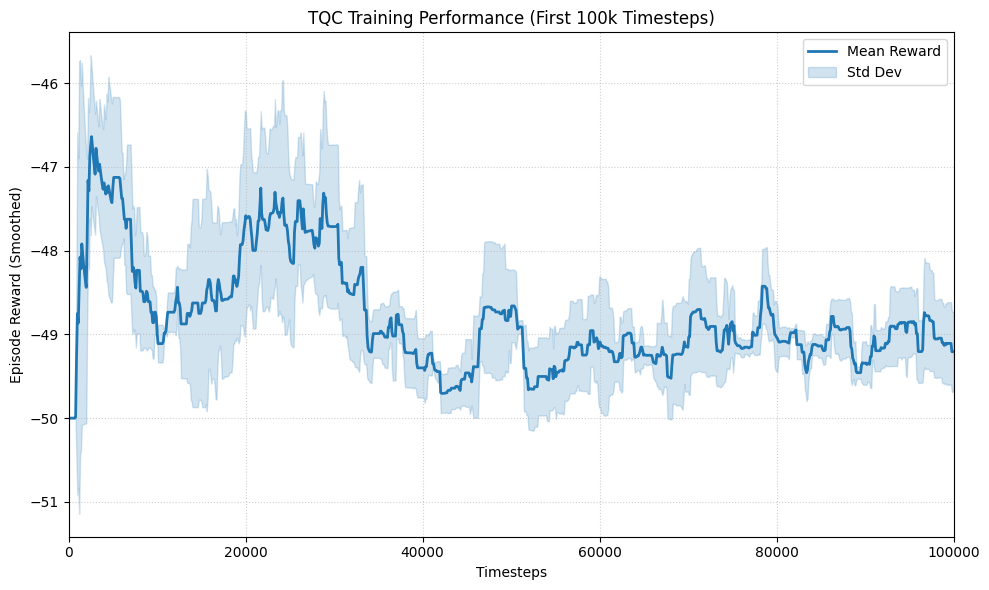

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import glob

log_files = glob.glob('logs/tqc/FetchPickAndPlace-v4_sparse_her_*/0.monitor.csv')
all_interp_rewards = []
common_timesteps = np.linspace(0, 100000, 1000)

for file in log_files:
    df = pd.read_csv(file, skiprows=1)
    
    df['cum_steps'] = df['l'].cumsum()
    
    mask = df['cum_steps'] <= 100000
    df_limited = df[mask]
    
    smoothed_r = df_limited['r'].rolling(window=100, min_periods=1).mean().values
    steps = df_limited['cum_steps'].values
    
    if len(steps) > 0:
        interp_r = np.interp(common_timesteps, steps, smoothed_r)
        all_interp_rewards.append(interp_r)

reward_matrix = np.vstack(all_interp_rewards)
mean_reward = np.mean(reward_matrix, axis=0)
std_reward = np.std(reward_matrix, axis=0)

plt.figure(figsize=(10, 6))
plt.plot(common_timesteps, mean_reward, color='#1f77b4', label='Mean Reward', linewidth=2)
plt.fill_between(common_timesteps, mean_reward - std_reward, mean_reward + std_reward, 
                 color='#1f77b4', alpha=0.2, label='Std Dev')

plt.title('TQC Training Performance (First 100k Timesteps)')
plt.xlabel('Timesteps')
plt.ylabel('Episode Reward (Smoothed)')
plt.xlim(0, 100000)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

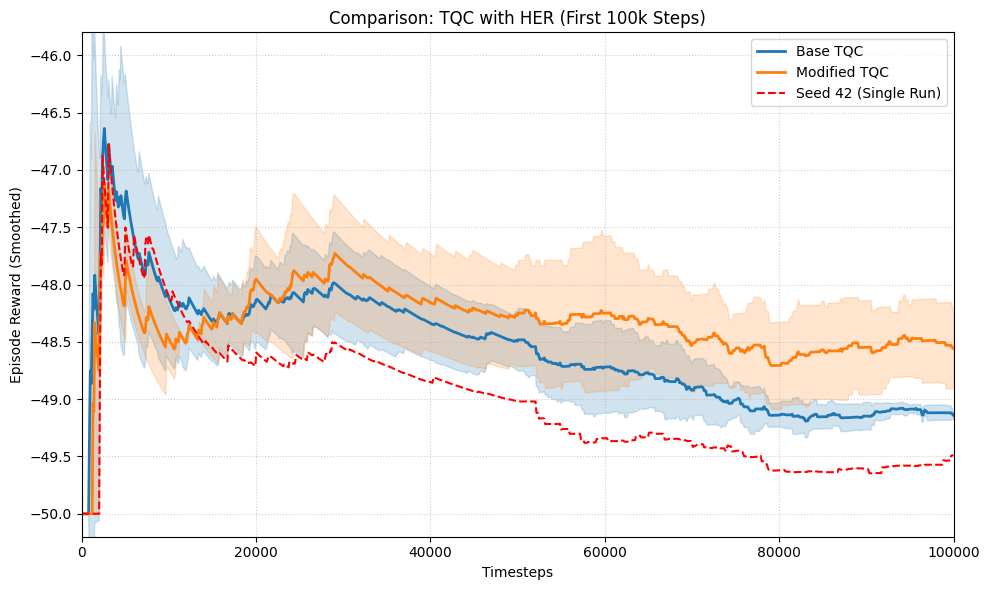

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import glob

base_files = glob.glob('logs/tqc/FetchPickAndPlace-v4_sparse_her_*/0.monitor.csv')
mod_files = glob.glob('logs/tqc/FetchPickAndPlaceModified-v0_sparse_her_*/0.monitor.csv')
single_file = glob.glob('logs/tqc/FetchPickAndPlace-v4_sparse_42/0.monitor.csv')
common_timesteps = np.linspace(0, 100000, 1000)

def process_logs(files):
    interp_list = []
    for file in files:
        df = pd.read_csv(file, skiprows=1)
        df['cum_steps'] = df['l'].cumsum()
        mask = df['cum_steps'] <= 100000
        df_ltd = df[mask]
        
        if len(df_ltd) > 0:
            smoothed = df_ltd['r'].rolling(window=1000, min_periods=1).mean().values
            steps = df_ltd['cum_steps'].values
            interp_list.append(np.interp(common_timesteps, steps, smoothed))
    return np.vstack(interp_list) if interp_list else None

base_matrix = process_logs(base_files)
mod_matrix = process_logs(mod_files)
single_run = process_logs(single_file)

plt.figure(figsize=(10, 6))

# the TQC + HER
if base_matrix is not None:
    mean_base = np.mean(base_matrix, axis=0)
    std_base = np.std(base_matrix, axis=0)
    plt.plot(common_timesteps, mean_base, color='#1f77b4', label='Base TQC', linewidth=2)
    plt.fill_between(common_timesteps, mean_base - std_base, mean_base + std_base, 
                     color='#1f77b4', alpha=0.2)

# TQC + HER + Reward shaping
if mod_matrix is not None:
    mean_mod = np.mean(mod_matrix, axis=0)
    std_mod = np.std(mod_matrix, axis=0)
    plt.plot(common_timesteps, mean_mod, color='#ff7f0e', label='Modified TQC', linewidth=2)
    plt.fill_between(common_timesteps, mean_mod - std_mod, mean_mod + std_mod, 
                     color='#ff7f0e', alpha=0.2)
    
# TQC only
if single_run is not None:
    plt.plot(common_timesteps, single_run[0], color='red', label='Seed 42 (Single Run)', linewidth=1.5, linestyle='--')

plt.title('Comparison: TQC with HER (First 100k Steps)')
plt.xlabel('Timesteps')
plt.ylabel('Episode Reward (Smoothed)')
plt.xlim(0, 100000)

plt.ylim(-50.2, -45.8)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

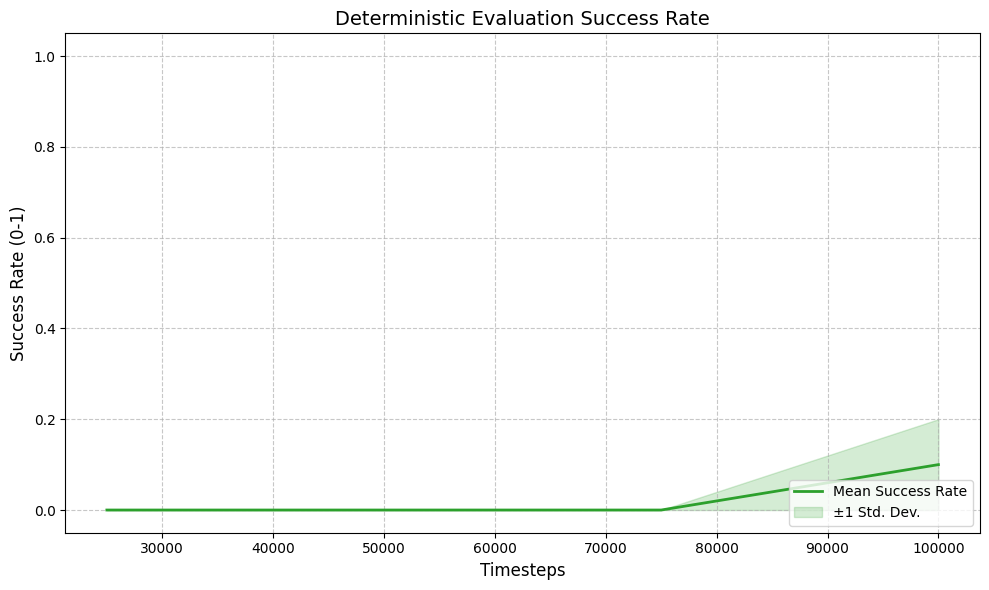

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

# Use the path to your log folder
files = sorted(glob.glob("logs/tqc/FetchPickAndPlaceModified-v0_sparse_her_*/evaluations.npz"))

all_successes = []
timesteps = None

for f in files:
    data = np.load(f)
    
    # Capture the common x-axis (timesteps) from the first file
    if timesteps is None:
        timesteps = data['timesteps']
    
    # data['successes'] is shape (num_checkpoints, num_episodes_per_check)
    # We average across episodes to get a rate between 0 and 1 for this seed
    seed_success_rate = np.mean(data['successes'], axis=1)
    all_successes.append(seed_success_rate)

# Stack seeds into a matrix: (num_seeds, num_checkpoints)
success_matrix = np.vstack(all_successes)

# Calculate stats across the seed axis
mean_success = np.mean(success_matrix, axis=0)
std_success = np.std(success_matrix, axis=0)

plt.figure(figsize=(10, 6))

# Plot the mean line
plt.plot(timesteps, mean_success, color='#2ca02c', label='Mean Success Rate', linewidth=2)

# Plot the standard deviation as a shaded area
plt.fill_between(timesteps, 
                 mean_success - std_success, 
                 mean_success + std_success, 
                 color='#2ca02c', alpha=0.2, label='±1 Std. Dev.')

# Aesthetics
plt.title("Deterministic Evaluation Success Rate", fontsize=14)
plt.xlabel("Timesteps", fontsize=12)
plt.ylabel("Success Rate (0-1)", fontsize=12)
plt.ylim(-0.05, 1.05)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='lower right')
plt.tight_layout()

# Save and Show
plt.savefig('evaluation_success_rate.png', dpi=300)
plt.show()

###### Training plot mean + std (TQC + HER + Reward Shaping)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import glob

log_files = glob.glob('logs/tqc/FetchPickAndPlaceModified-v0_sparse_her_*/0.monitor.csv')
all_interp_rewards = []
common_timesteps = np.linspace(0, 100000, 1000)

for file in log_files:
    df = pd.read_csv(file, skiprows=1)
    
    df['cum_steps'] = df['l'].cumsum()
    
    mask = df['cum_steps'] <= 100000
    df_limited = df[mask]
    
    smoothed_r = df_limited['r'].rolling(window=100, min_periods=1).mean().values
    steps = df_limited['cum_steps'].values
    
    if len(steps) > 0:
        interp_r = np.interp(common_timesteps, steps, smoothed_r)
        all_interp_rewards.append(interp_r)

reward_matrix = np.vstack(all_interp_rewards)
mean_reward = np.mean(reward_matrix, axis=0)
std_reward = np.std(reward_matrix, axis=0)

plt.figure(figsize=(10, 6))
plt.plot(common_timesteps, mean_reward, color='#1f77b4', label='Mean Reward', linewidth=2)
plt.fill_between(common_timesteps, mean_reward - std_reward, mean_reward + std_reward, 
                 color='#1f77b4', alpha=0.2, label='Std Dev')

plt.title('TQC Training Performance (First 100k Timesteps)')
plt.xlabel('Timesteps')
plt.ylabel('Episode Reward (Smoothed)')
plt.xlim(0, 100000)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()